In [126]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import glob
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms
import cv2
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     print(dirname)
    # for filename in filenames:
    #     print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

CUDA available: True
GPU count: 2


In [146]:
PATH = "/kaggle/input/animefacedataset/"
IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_VECTOR_SIZE = 100
NUMBER_CHANNEL = 3
GENERATOR_FEATURE_MAP = 64
DISCRIMINATOR_FEATURE_MAP = 64
EPOCHS = 15
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [132]:
dataset = datasets.ImageFolder(
    root = PATH,
    transform= transforms.Compose(
        [
            transforms.Resize(size=IMAGE_SIZE),
            transforms.CenterCrop(size=IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]
    )

)
img_dataloader = DataLoader(
    dataset,
    batch_size = BATCH_SIZE,
)

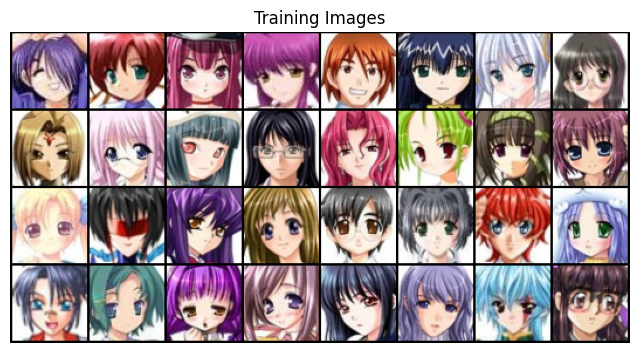

In [147]:
real_batch = next(iter(img_dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(DEVICE)[:32], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [134]:
def weight_init(model):
  classname = model.__class__.__name__
  if classname.find("conv") != -1:
    nn.init.normal_(model.weight.data,0.0,0.02)
  elif classname.find('BatchNorm') != -1:
      nn.init.normal_(model.weight.data, 1.0, 0.02)
      nn.init.constant_(model.bias.data, 0)

In [135]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.Convlayers = nn.Sequential(
        nn.ConvTranspose2d(in_channels=LATENT_VECTOR_SIZE,out_channels=GENERATOR_FEATURE_MAP*8,kernel_size=4,stride=1,padding=0),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP*8),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP*8,out_channels=GENERATOR_FEATURE_MAP*4,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP*4),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP*4,out_channels=GENERATOR_FEATURE_MAP*2,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP*2),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP*2,out_channels=GENERATOR_FEATURE_MAP,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP,out_channels=NUMBER_CHANNEL,kernel_size=4,stride=2,padding=1),
        nn.Tanh()
    ) 

  def forward(self,x):
    output = self.Convlayers(x)
    return output

class Discrimator(nn.Module):

  def __init__(self):
    super().__init__()
    self.predictor = nn.Sequential(

        nn.Conv2d(in_channels = NUMBER_CHANNEL,out_channels=DISCRIMINATOR_FEATURE_MAP,kernel_size=4,stride=2,padding=1),
        nn.LeakyReLU(0.2,inplace=False),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP,out_channels=DISCRIMINATOR_FEATURE_MAP * 2,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(DISCRIMINATOR_FEATURE_MAP * 2),
        nn.LeakyReLU(0.2,inplace=False),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP * 2 ,out_channels=DISCRIMINATOR_FEATURE_MAP * 4,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(DISCRIMINATOR_FEATURE_MAP * 4),
        nn.LeakyReLU(0.2,inplace=False),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP * 4,out_channels=DISCRIMINATOR_FEATURE_MAP * 8, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(DISCRIMINATOR_FEATURE_MAP * 8),
        nn.LeakyReLU(0.2,inplace=False),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP * 8, out_channels = 1, kernel_size = 4, stride=1, padding = 0),
        nn.Sigmoid(),
    )

  def forward(self,x):
    output = self.predictor(x)
    return output 

print("Model Created")

Model Created


In [136]:
Generator_net = Generator().to(DEVICE)
Discrimator_net = Discrimator().to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    Generator_net = torch.nn.DataParallel(Generator_net)
    Discrimator_net = torch.nn.DataParallel(Discrimator_net)

Generator_net.apply(weight_init)
Discrimator_net.apply(weight_init)

Using 2 GPUs


DataParallel(
  (module): Discrimator(
    (predictor): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2)
      (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): LeakyReLU(negative_slope=0.2)
      (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): LeakyReLU(negative_slope=0.2)
      (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): LeakyReLU(negative_slope=0.2)
      (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
      (12): Sigmoid()
    )
  )
)

In [140]:
criterion = nn.BCELoss()

real_label = 0.9
fake_label = 0.1

img_list = []
G_losses = []
D_losses = []
iters = 0


fixed_noise = torch.randn(64, LATENT_VECTOR_SIZE, 1, 1, device=DEVICE)
Optimizer_Generator = torch.optim.Adam(Generator_net.parameters(),lr=0.0002,betas=(0.5,0.999))
Optimizer_Discrimator = torch.optim.Adam(Discrimator_net.parameters(),lr=0.0001,betas=(0.5,0.999))
fixed_noise.shape

torch.Size([64, 100, 1, 1])

In [141]:
def show_images(generator):
    z = torch.randn(BATCH_SIZE, LATENT_VECTOR_SIZE,1,1).to(DEVICE)
    fake_imgs = generator(z).view(-1,3,64,64).cpu().detach()
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title("Generated Images")
    plt.imshow(np.transpose(vutils.make_grid(fake_imgs.to(DEVICE)[:32], padding=2, normalize=True).cpu(),(1,2,0)))
    plt.show()

In [ ]:
print("Starting Training Loop...")
for epoch in range(EPOCHS):
    for i, data in enumerate(img_dataloader):


        Optimizer_Discrimator.zero_grad()
        
        real_imgs = data[0].to(DEVICE)
        b_size = real_imgs.size(0)
        
        # --- Real batch ---
        labels_real = torch.full((b_size,), real_label, device=DEVICE)
        output_real = Discrimator_net(real_imgs).reshape(-1)
        errD_real = criterion(output_real, labels_real)
        errD_real.backward()
        
        # --- Fake batch ---
        noise = torch.randn(b_size, LATENT_VECTOR_SIZE, 1, 1, device=DEVICE)
        fake_imgs = Generator_net(noise)
        
        labels_fake = torch.full((b_size,), fake_label, device=DEVICE)
        output_fake = Discrimator_net(fake_imgs.detach()).reshape(-1)
        errD_fake = criterion(output_fake, labels_fake)
        errD_fake.backward()
        
        errD = errD_real + errD_fake
        Optimizer_Discrimator.step()
        

        Optimizer_Generator.zero_grad()
        
        noise = torch.randn(b_size, LATENT_VECTOR_SIZE, 1, 1, device=DEVICE)
        fake_imgs_G = Generator_net(noise)
        
        labels_gen = torch.full((b_size,), real_label, device=DEVICE)
        output = Discrimator_net(fake_imgs_G).reshape(-1)
        errG = criterion(output, labels_gen)
        errG.backward()
        Optimizer_Generator.step()


        if i % 50 == 0:
            print(
                f"[{epoch}/{EPOCHS}][{i}/{len(img_dataloader)}] "
                f"Loss_D: {errD.item():.4f} "
                f"Loss_G: {errG.item():.4f}"
            )

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if iters % 500 == 0:
            with torch.no_grad():
                fake = Generator_net(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))
        iters += 1

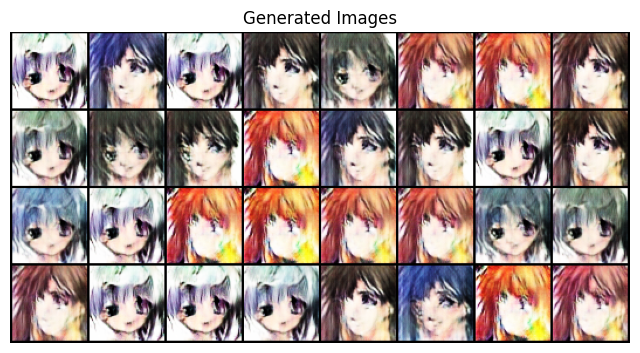

In [145]:
show_images(Generator_net)